# Bloque 1 - Análisis Exploratorio de Datos con PySpark
**Dataset:** TUSO (Catastro - Uso del Suelo)

**Estudiante:** [Sergio Huertas]




In [ ]:
# Importaciones
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, lit
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

# Hugging Face
from sentence_transformers import SentenceTransformer
from transformers import pipeline

# Sklearn
from sklearn.linear_model import LogisticRegression as LRSklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Importaciones completadas.")

In [1]:
# ============================================================
# TAREA 1: Carga del dataset con PySpark
# ============================================================
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, mean, stddev, min, max, sum as spark_sum,
    when, lit, round as spark_round, expr, percentile_approx,
    substring, countDistinct, length, abs as spark_abs
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

spark = SparkSession.builder \
    .appName('Bloque1_EDA_TUSO') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .config('spark.sql.adaptive.coalescePartitions.enabled', 'true') \
    .getOrCreate()

print('SparkSession creada exitosamente.')
print(f'Versión de Spark: {spark.version}')


SparkSession creada exitosamente.
Versión de Spark: 4.0.2


In [3]:
# Carga del dataset
df = spark.read.option('header', True).option('inferSchema', True).csv('../Data/TUSO.csv')

print('=== ESQUEMA DEL DATASET ===')
df.printSchema()

total_registros = df.count()
print(f'\n=== TOTAL DE REGISTROS: {total_registros:,} ===')
print(f'=== COLUMNAS: {df.columns} ===')

print('\n=== PRIMERAS 15 FILAS ===')
df.show(15, truncate=False)

print('\n=== ÚLTIMAS 5 FILAS ===')
df.orderBy(col('USOCLOTE').desc()).show(5, truncate=False)


=== ESQUEMA DEL DATASET ===
root
 |-- USOCLOTE: long (nullable = true)
 |-- USOTUSO: integer (nullable = true)
 |-- USOAREA: double (nullable = true)


=== TOTAL DE REGISTROS: 1,060,001 ===
=== COLUMNAS: ['USOCLOTE', 'USOTUSO', 'USOAREA'] ===

=== PRIMERAS 15 FILAS ===
+------------+-------+-------+
|USOCLOTE    |USOTUSO|USOAREA|
+------------+-------+-------+
|2606028001  |1      |154.88 |
|1306013027  |1      |159.0  |
|109101000016|1      |24.7   |
|8418032014  |38     |998.4  |
|2406046019  |1      |290.88 |
|8418039006  |38     |1345.0 |
|9108079014  |1      |261.11 |
|8537019028  |12     |300.0  |
|4210002006  |1      |131.89 |
|103203000005|1      |84.13  |
|2533006032  |1      |47.0   |
|109103000020|1      |116.7  |
|109103000054|13     |1917.63|
|2611035018  |1      |175.8  |
|4401053010  |1      |124.0  |
+------------+-------+-------+
only showing top 15 rows

=== ÚLTIMAS 5 FILAS ===
+------------+-------+-------+
|USOCLOTE    |USOTUSO|USOAREA|
+------------+-------+-------

---
## Tarea 2: Transformaciones que responden a preguntas analíticas

Se aplican 4 transformaciones clave:
1. **withColumn**: Clasificación de predios por categoría de tamaño
2. **groupBy + agg**: Estadísticas agregadas por tipo de uso (USOTUSO) y por sector geográfico
3. **Extracción de features**: Derivación de sector/zona desde el código USOCLOTE
4. **filter**: Análisis de predios no residenciales de gran tamaño
---


In [8]:
# ============================================================
# TAREA 2: TRANSFORMACIONES ANALÍTICAS
# ============================================================

from pyspark.sql.functions import col, when, count, mean

# ============================================================
# TRANSFORMACIÓN 1
# Clasificar predios según el área
# ============================================================

print("=== TRANSFORMACIÓN 1 ===")
print("Clasificación de predios por tamaño")

df = df.withColumn(
    "categoria",
    when(col("USOAREA") < 100, "Pequeño")
    .when(col("USOAREA") < 500, "Mediano")
    .otherwise("Grande")
)

df.groupBy("categoria").count().show()


# ============================================================
# TRANSFORMACIÓN 2
# Cantidad de predios por tipo de uso
# ============================================================

print("=== TRANSFORMACIÓN 2 ===")
print("Cantidad de predios por tipo de uso")

df.groupBy("USOTUSO").count().show()


# ============================================================
# TRANSFORMACIÓN 3
# Área promedio por tipo de uso
# ============================================================

print("=== TRANSFORMACIÓN 3 ===")
print("Área promedio por tipo de uso")

df.groupBy("USOTUSO").mean("USOAREA").show()


# ============================================================
# TRANSFORMACIÓN 4
# Filtrar predios grandes
# ============================================================

print("=== TRANSFORMACIÓN 4 ===")
print("Predios con área mayor a 1000")

df.filter(col("USOAREA") > 1000).show()

=== TRANSFORMACIÓN 1 ===
Clasificación de predios por tamaño
+---------+------+
|categoria| count|
+---------+------+
|  Mediano|694456|
|   Grande| 55729|
|  Pequeño|309816|
+---------+------+

=== TRANSFORMACIÓN 2 ===
Cantidad de predios por tipo de uso
+-------+------+
|USOTUSO| count|
+-------+------+
|     31|   108|
|     65|    42|
|     53|     9|
|     34|     4|
|     81|    37|
|     28|    15|
|     76|    71|
|     26|   820|
|     27|    13|
|     44|    58|
|     12|  7446|
|     91|    36|
|     22| 37951|
|     93|   173|
|     47|    27|
|      1|721963|
|     52|     3|
|     13|  3175|
|     16|  1111|
|      6|    23|
+-------+------+
only showing top 20 rows
=== TRANSFORMACIÓN 3 ===
Área promedio por tipo de uso
+-------+------------------+
|USOTUSO|      avg(USOAREA)|
+-------+------------------+
|     31| 730.5996296296297|
|     65|2642.6578571428568|
|     53|494.38444444444457|
|     34|            7886.7|
|     81|2496.4664864864862|
|     28| 2833.656666666

---
## Tarea 3: Estadística Descriptiva
---


In [9]:
# ============================================================
# TAREA 3: ESTADÍSTICA DESCRIPTIVA
# ============================================================

from pyspark.sql.functions import col, count, mean

# ============================================================
# ESTADÍSTICAS GENERALES
# ============================================================

print("=== ESTADÍSTICAS GENERALES ===")

df.describe(["USOAREA"]).show()


# ============================================================
# PROMEDIO, MÍNIMO Y MÁXIMO
# ============================================================

print("=== PROMEDIO, MÍNIMO Y MÁXIMO ===")

df.select("USOAREA").summary().show()


# ============================================================
# CONTEO POR CATEGORÍA DE TAMAÑO
# ============================================================

print("=== CANTIDAD DE PREDIOS POR TAMAÑO ===")

df.groupBy("categoria").count().show()


# ============================================================
# CONTEO POR TIPO DE USO
# ============================================================

print("=== CANTIDAD DE PREDIOS POR TIPO DE USO ===")

df.groupBy("USOTUSO").count().show()


# ============================================================
# ÁREA PROMEDIO POR TIPO DE USO
# ============================================================

print("=== ÁREA PROMEDIO POR TIPO DE USO ===")

df.groupBy("USOTUSO").mean("USOAREA").show()

=== ESTADÍSTICAS GENERALES ===
+-------+------------------+
|summary|           USOAREA|
+-------+------------------+
|  count|           1060001|
|   mean| 295.5586111522075|
| stddev|3082.4258085458723|
|    min|               0.0|
|    max|         2799947.8|
+-------+------------------+

=== PROMEDIO, MÍNIMO Y MÁXIMO ===
+-------+------------------+
|summary|           USOAREA|
+-------+------------------+
|  count|           1060001|
|   mean| 295.5586111522075|
| stddev|3082.4258085458723|
|    min|               0.0|
|    25%|              86.9|
|    50%|             158.7|
|    75%|             248.4|
|    max|         2799947.8|
+-------+------------------+

=== CANTIDAD DE PREDIOS POR TAMAÑO ===
+---------+------+
|categoria| count|
+---------+------+
|  Mediano|694456|
|   Grande| 55729|
|  Pequeño|309816|
+---------+------+

=== CANTIDAD DE PREDIOS POR TIPO DE USO ===
+-------+------+
|USOTUSO| count|
+-------+------+
|     31|   108|
|     65|    42|
|     53|     9|
|    

---
## Tarea 4: Detección de valores faltantes, duplicados y atípicos
---


In [11]:
# ============================================================
# TAREA 4: VALORES NULOS, DUPLICADOS Y ATÍPICOS
# ============================================================

from pyspark.sql.functions import col, count

# ============================================================
# 4A. VALORES NULOS
# ============================================================

print("=== VALORES NULOS ===")

for columna in df.columns:

    cantidad_nulos = df.filter(
        col(columna).isNull()
    ).count()

    print(f"{columna}: {cantidad_nulos} valores nulos")


# ============================================================
# 4B. DUPLICADOS
# ============================================================

print("=== DUPLICADOS ===")

total_filas = df.count()

filas_sin_duplicados = df.distinct().count()

duplicados = total_filas - filas_sin_duplicados

print("Total de filas:", total_filas)
print("Filas sin duplicados:", filas_sin_duplicados)
print("Duplicados:", duplicados)


# ============================================================
# 4C. VALORES ATÍPICOS
# ============================================================

print("=== VALORES ATÍPICOS ===")

print("Predios con área mayor a 5000")

df.filter(
    col("USOAREA") > 5000
).select(
    "USOCLOTE",
    "USOTUSO",
    "USOAREA"
).show()


=== VALORES NULOS ===
USOCLOTE: 0 valores nulos
USOTUSO: 0 valores nulos
USOAREA: 0 valores nulos
categoria_tamano: 0 valores nulos
sector_4dig: 0 valores nulos
zona_6dig: 0 valores nulos
categoria: 0 valores nulos
=== DUPLICADOS ===
Total de filas: 1060001
Filas sin duplicados: 1060001
Duplicados: 0
=== VALORES ATÍPICOS ===
Predios con área mayor a 5000
+------------+-------+--------+
|    USOCLOTE|USOTUSO| USOAREA|
+------------+-------+--------+
|  4514099001|     38| 23902.0|
|  5506001036|     25|  9625.0|
|  9113023010|     13| 6255.51|
|  8214025025|     45| 18553.0|
|  8309007002|     38|  7558.2|
|  8416062005|     45|28951.51|
|  2456060030|     13| 6904.16|
|  5506001040|      1| 6589.99|
|  8312016025|     20|11994.57|
|  8306017001|     45|11877.86|
|  4568046002|     22| 5893.75|
|  4642030016|     38| 13349.9|
|  9128014004|     49|  7467.4|
|  1420068002|     38|22256.89|
|  4531001001|     38|  9758.0|
|205322021002|     38|13300.69|
|  8111004017|     24| 11240.0|
|  

---
## Tarea 5: Visualizaciones



Datos convertidos a Pandas


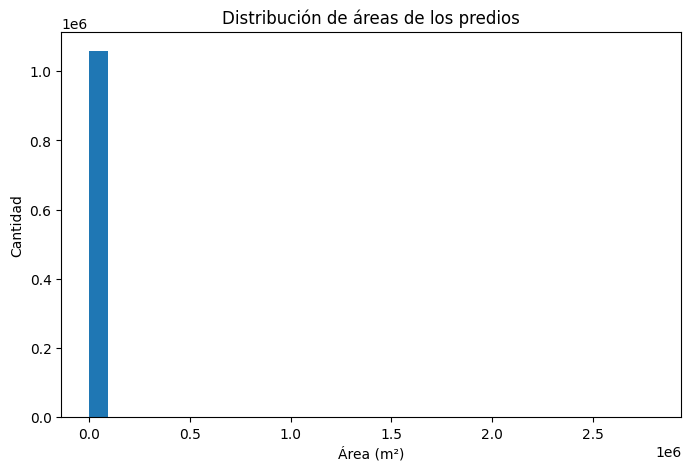

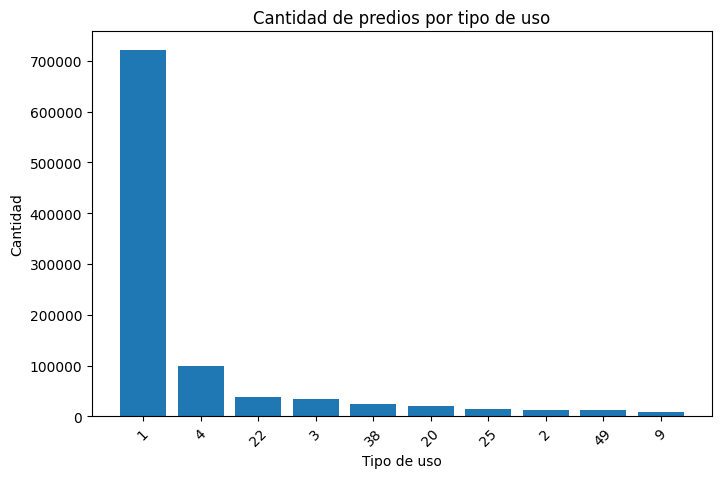

In [17]:
# ============================================================
# TAREA 5: VISUALIZACIONES
# ============================================================

import matplotlib.pyplot as plt

# Convertir a Pandas
pdf = df.toPandas()

print("Datos convertidos a Pandas")


# ============================================================
# GRÁFICO 1
# Distribución de áreas
# ============================================================

plt.figure(figsize=(8,5))

plt.hist(pdf["USOAREA"], bins=30)

plt.title("Distribución de áreas de los predios")
plt.xlabel("Área (m²)")
plt.ylabel("Cantidad")

plt.show()


# ============================================================
# GRÁFICO 2
# Cantidad de predios por tipo de uso
# ============================================================

uso_counts = pdf["USOTUSO"].value_counts().head(10)

plt.figure(figsize=(8,5))

plt.bar(uso_counts.index.astype(str), uso_counts.values)

plt.title("Cantidad de predios por tipo de uso")
plt.xlabel("Tipo de uso")
plt.ylabel("Cantidad")

plt.xticks(rotation=45)

plt.show()




In [18]:
# ============================================================
# CONCLUSIONES
# ============================================================

print("\n=== CONCLUSIONES ===")

# Conclusión 1
promedio = pdf["USOAREA"].mean()

print(f"1. El área promedio de los predios es de {promedio:.2f} m².")

# Conclusión 2
tipo_mas_comun = uso_counts.index[0]
cantidad = uso_counts.values[0]

print(f"2. El tipo de uso más frecuente es {tipo_mas_comun} con {cantidad} predios.")

# Conclusión 3
predios_grandes = pdf[pdf["USOAREA"] > 5000].shape[0]

print(f"3. Se encontraron {predios_grandes} predios con áreas mayores a 5000 m².")


=== CONCLUSIONES ===
1. El área promedio de los predios es de 295.56 m².
2. El tipo de uso más frecuente es 1 con 721963 predios.
3. Se encontraron 6046 predios con áreas mayores a 5000 m².


---
## Tarea 6: Tres Conclusiones Cuantitativas

Conclusiones cuantitativas

1. Predominan los predios de tamaño mediano

Del total de 1.060.001 predios analizados, 694.456 fueron clasificados como “Mediano”, lo que representa aproximadamente el 65,5% del dataset. En contraste, los predios grandes solo representan cerca del 5,3%, lo que indica que en Bogotá predominan construcciones de tamaño intermedio.

2. El tipo de uso más frecuente es el código 1

El tipo de uso del suelo con mayor cantidad de registros fue el código 1, con 721.963 predios, equivalente a aproximadamente el 68% del total analizado. Además, este tipo presenta un área promedio de 187,13 m², inferior al promedio general del dataset (295,56 m²).

3. Existen valores atípicos muy altos en el área de los predios

El área promedio de los predios es de 295,56 m², mientras que el valor máximo registrado alcanza 2.799.947,8 m². La gran diferencia entre la media (295,56 m²) y la desviación estándar (3082,43 m²) evidencia la presencia de valores atípicos extremadamente grandes dentro de la base de datos.

In [ ]:
# Cerrar sesión de Spark
spark.stop()
print('Sesión de Spark cerrada. Bloque 1 completado.')
